In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

# Chargement du dataset SVHN
(ds_train, ds_test), ds_info = tfds.load(
    'svhn_cropped',
    split=['train', 'test'],
    as_supervised=True,  # Retourne un tuple (img, label) au lieu d'un dictionnaire {'image': img, 'label': label}
    with_info=True  # Retourne le tuple avec les informations du dataset
)

def preprocess(images, labels):
    # Normalisation des images
    images = tf.cast(images, tf.float32) / 255.0
    # One-hot encoding des étiquettes
    labels = tf.one_hot(labels, depth=10)
    return images, labels

# Prétraitement des données
ds_train = ds_train.map(preprocess).batch(32)
ds_test = ds_test.map(preprocess).batch(32)

# Taille des images dans SVHN
hauteur, largeur, canaux = ds_info.features['image'].shape
num_classes = ds_info.features['label'].num_classes

# Construction du modèle adapté à la reconnaissance de séquences de chiffres
model = models.Sequential()

# Base convolutive pour l'extraction de caractéristiques
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(hauteur, largeur, canaux)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))

# Adaptation pour la reconnaissance de séquences
# Ici, vous devez ajuster `sequence_length` et `features` selon la sortie de votre couche convolutive
model.add(layers.Flatten())  # Utilisez Flatten comme simplification pour cet exemple
model.add(layers.Dense(128, activation='relu'))

# Couche de sortie pour la classification de chaque chiffre dans la séquence
model.add(layers.Dense(num_classes, activation='softmax'))

# Compilation du modèle
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Configuration de l'Early Stopping
early_stopping = EarlyStopping(
    monitor='val_loss',  # Surveille la perte de validation
    patience=3,  # Nombre d'époques sans amélioration après lesquelles l'entraînement sera arrêté
    verbose=1,
    restore_best_weights=True  # Restaure les meilleurs poids trouvés
)

# Entraînement du modèle
historique = model.fit(
    ds_train,
    epochs=10,
    validation_data=ds_test,
    callbacks=[early_stopping]  # Ajoute l'Early Stopping à la liste des callbacks
)

#model.save('./models/svhn_model.keras')

c:\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dl Completed...:  67%|██████▋   | 2/3 [03:31<00:40, 40.71s/ url]

In [10]:
# Évaluation du modèle sur l'ensemble de test
test_loss, test_acc = model.evaluate(ds_test)

print(f"Perte de test: {test_loss}")
print(f"Précision de test: {test_acc}")

814/814 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8874 - loss: 0.3845
Perte de test: 0.394876092672348
Précision de test: 0.8884450197219849


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step


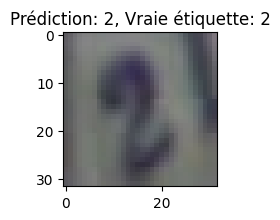

In [18]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt

# Charger le modèle pré-entraîné
model = tf.keras.models.load_model('svhn_model.keras')

# Charger une image unique de l'ensemble de test SVHN
ds_test_single = tfds.load('svhn_cropped', split='test', as_supervised=True)

# Prendre une image spécifique
for image, label in ds_test_single.take(8):  # Utilisez `.take(1)` pour obtenir une image
    test_image, test_label = image, label

# Prétraiter l'image
test_image = tf.cast(test_image, tf.float32) / 255.0
test_image = tf.expand_dims(test_image, 0)  # Ajouter une dimension pour le batch

# Faire une prédiction
predictions = model.predict(test_image)
predicted_class = np.argmax(predictions, axis=1)[0]

# Afficher l'image et la prédiction
plt.figure(figsize=(2, 2))
plt.imshow(test_image[0].numpy())
plt.title(f'Prédiction: {predicted_class}, Vraie étiquette: {test_label.numpy()}')
plt.show()

In [ ]:
from utils import plot

plot(historique)

In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Charger le modèle pré-entraîné
model = tf.keras.models.load_model('svhn_model.keras')

# Préparer les données de test pour la prédiction
ds_test = ds_test.unbatch().batch(1)  # Assurez-vous que ds_test est défini et prétraité comme montré précédemment

# Prédire les étiquettes pour le dataset de test
y_pred = []
y_true = []
for img, label in ds_test:
    # Prédire la classe de l'image
    pred = model.predict(img)
    pred_class = np.argmax(pred, axis=1)[0]
    true_class = np.argmax(label.numpy(), axis=1)[0]
    y_pred.append(pred_class)
    y_true.append(true_class)

# Calculer la matrice de confusion
conf_matrix = confusion_matrix(y_true, y_pred)

# Afficher la matrice de confusion
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='g', cmap='Blues')
plt.xlabel('Prédit')
plt.ylabel('Vrai')
plt.title('Matrice de confusion')
plt.show()